# Per-Drug Sensitivity of GA-Selected k=8 Nodes

For each node in the GA-evolved k=8 feature set (network 0, `max_num_features=8`),
we compute how much that node's equilibrium state deviates from control when each
specific drug perturbation is applied.

**Sensitivity metric**: mean |state_drug(node) - state_control(node)| averaged over
all 10 initial conditions × 10 simulation steps for network 0.

**Target nodes** (GA best k=8, network 0):
`{node-624, node-1530, node-1917, node-2032, node-2550, node-2935, node-3201, node-3258}`

## Outputs
1. **Disk plots** (2×4 grid): one polar bar chart per node, 10 slices = 10 drugs,
   bar height + fill color both encode Hamming distance. Same colormap scale across all plots.
2. **Summary heatmap**: nodes × drugs, annotated with exact values.

## Section 0: Setup & Data Loading

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

sns.set_theme(style='whitegrid')

In [ ]:
STATES_FILE = '../data/drug-fixed-targets-v7/N5000/derived/states-1772488362007.csv'
print('Loading states (large file, may take a moment)...')
states_df = pd.read_csv(STATES_FILE)
print(f'  shape: {states_df.shape}')
print(f'  columns[:6]: {list(states_df.columns[:6])}')
print(f'  drug_name values: {sorted(states_df.drug_name.unique())}')
states_df.head(2)

Loading states (large file, may take a moment)...
  shape: (55000, 5004)
  columns[:6]: ['drug_name', 'original_network_idx', 'initial_condition_idx', 'step_num', 'node-0', 'node-1']
  drug_name values: ['control', 'drug-1', 'drug-10', 'drug-2', 'drug-3', 'drug-4', 'drug-5', 'drug-6', 'drug-7', 'drug-8', 'drug-9']


,drug_name,original_network_idx,initial_condition_idx,step_num,node-0,node-1,node-2,node-3,node-4,node-5,...,node-4990,node-4991,node-4992,node-4993,node-4994,node-4995,node-4996,node-4997,node-4998,node-4999
0,control,0,0,0,False,False,True,True,True,True,...,False,True,False,False,False,True,True,True,True,True
1,control,0,0,1,False,False,False,True,False,True,...,False,False,False,False,False,True,True,False,True,True


In [26]:
NETWORK_IDX = 5

parse = lambda s: list(map(lambda node_name: int(node_name.split('-')[-1]), list(eval(s))))
# GA-selected k=8 nodes for network 0 (max_num_features=8, final generation)
# NODES_OF_INTEREST = [624, 1530, 1917, 2032, 2550, 2935, 3201, 3258] # network 0
NODES_OF_INTEREST = [4166, 1500, 4023, 2468, 686, 2339, 1147, 65] # network 1
NODES_OF_INTEREST = parse("{'node-1747', 'node-260', 'node-3064', 'node-4166', 'node-562', 'node-1707', 'node-3061', 'node-4377'}") # network 2
NODES_OF_INTEREST = parse("{'node-3667', 'node-1046', 'node-461', 'node-1741', 'node-456', 'node-3115', 'node-1868', 'node-1111'}") # network 3
NODES_OF_INTEREST = parse("{'node-3440', 'node-3394', 'node-3559', 'node-3569', 'node-4704', 'node-4070', 'node-1802', 'node-1896'}") # network 4
NODES_OF_INTEREST = parse("{'node-4087', 'node-555', 'node-3482', 'node-4372', 'node-3218', 'node-2670', 'node-7', 'node-3318'}") # network 5
NODE_COLS = [f'node-{n}' for n in NODES_OF_INTEREST]
print(f"{NODES_OF_INTEREST=}")

NODES_OF_INTEREST=[555, 4372, 7, 4087, 3218, 2670, 3482, 3318]


## Section 1: Compute Per-Drug Hamming Distance

For network 0, for each drug d and each node n:

```
sensitivity(d, n) = mean_{ic, step} |state_{d,ic,step}(n) - state_{control,ic,step}(n)|
```

States are aligned by `(initial_condition_idx, step_num)` before subtraction.

In [27]:
df0 = states_df[states_df['original_network_idx'] == NETWORK_IDX].copy()
print(f'Network {NETWORK_IDX} rows: {len(df0)}')
print(f'Conditions: {sorted(df0.drug_name.unique())}')

Network 5 rows: 1100
Conditions: ['control', 'drug-1', 'drug-10', 'drug-2', 'drug-3', 'drug-4', 'drug-5', 'drug-6', 'drug-7', 'drug-8', 'drug-9']


In [28]:
# Index control states by (initial_condition_idx, step_num) for alignment
control = (
  df0[df0['drug_name'] == 'control']
  .set_index(['initial_condition_idx', 'step_num'])[NODE_COLS]
  .astype(float)
  .sort_index()
)
print(f'Control matrix shape: {control.shape}  (10 ICs × 10 steps = 100 rows)')
control.head(3)

Control matrix shape: (100, 8)  (10 ICs × 10 steps = 100 rows)


node-555  node-4372  node-7  node-4087  \
initial_condition_idx step_num                                           
0                     0              1.0        1.0     0.0        0.0   
                      1              1.0        1.0     0.0        1.0   
                      2              1.0        1.0     0.0        0.0   

                                node-3218  node-2670  node-3482  node-3318  
initial_condition_idx step_num                                              
0                     0               0.0        0.0        1.0        0.0  
                      1               1.0        0.0        0.0        0.0  
                      2               1.0        0.0        1.0        0.0

In [29]:
# Sort drugs numerically: drug-1, drug-2, ..., drug-10
all_drugs = sorted(
  [d for d in df0['drug_name'].unique() if d != 'control'],
  key=lambda x: int(x.split('-')[1])
)
print(f'Drugs ({len(all_drugs)}): {all_drugs}')

hamming_rows = {}
for drug in all_drugs:
  treated = (
    df0[df0['drug_name'] == drug]
    .set_index(['initial_condition_idx', 'step_num'])[NODE_COLS]
    .astype(float)
    .sort_index()
  )
  diff = np.abs(treated.values - control.values)  # shape (100, 8)
  hamming_rows[drug] = diff.mean(axis=0)           # mean over 100 (IC, step) pairs

# hamming_df: rows = drugs, cols = nodes
hamming_df = pd.DataFrame(hamming_rows, index=NODE_COLS).T
print(f'\nPer-drug Hamming distance matrix shape: {hamming_df.shape}  (drugs × nodes)')
hamming_df

Drugs (10): ['drug-1', 'drug-2', 'drug-3', 'drug-4', 'drug-5', 'drug-6', 'drug-7', 'drug-8', 'drug-9', 'drug-10']

Per-drug Hamming distance matrix shape: (10, 8)  (drugs × nodes)


,node-555,node-4372,node-7,node-4087,node-3218,node-2670,node-3482,node-3318
drug-1,0.00,0.09,0.62,0.76,0.12,0.14,0.05,0.15
drug-2,0.00,0.09,0.67,0.62,0.35,0.15,0.05,0.83
drug-3,0.00,0.12,0.28,0.22,0.80,0.17,0.05,0.22
drug-4,0.00,0.91,0.19,0.76,0.88,0.86,0.05,0.89
drug-5,0.00,0.13,0.31,0.37,0.26,0.71,0.12,0.25
drug-6,0.00,0.91,0.36,0.35,0.08,0.07,0.06,0.07
drug-7,0.89,0.07,0.53,0.51,0.10,0.14,0.08,0.10
drug-8,0.01,0.78,0.62,0.54,0.34,0.71,0.21,0.70
drug-9,0.55,0.80,0.76,0.76,0.21,0.17,0.05,0.53
drug-10,0.00,0.27,0.64,0.76,0.18,0.68,0.20,0.84


In [30]:
print('Mean Hamming distance per node (avg over all drugs):')
print(hamming_df.mean().round(4).to_string())

print('\nMean Hamming distance per drug (avg over all 8 nodes):')
print(hamming_df.mean(axis=1).round(4).to_string())

print(f'\nGlobal vmax (for shared colormap scale): {hamming_df.values.max():.4f}')

Mean Hamming distance per node (avg over all drugs):
node-555     0.145
node-4372    0.417
node-7       0.498
node-4087    0.565
node-3218    0.332
node-2670    0.380
node-3482    0.092
node-3318    0.458

Mean Hamming distance per drug (avg over all 8 nodes):
drug-1     0.2412
drug-2     0.3450
drug-3     0.2325
drug-4     0.5675
drug-5     0.2688
drug-6     0.2375
drug-7     0.3025
drug-8     0.4888
drug-9     0.4788
drug-10    0.4462

Global vmax (for shared colormap scale): 0.9100


## Section 2: Disk Plots

One polar bar chart per node.
- **Slices**: 10 equal-angle slices, one per drug (drug-1 → drug-10 clockwise)
- **Bar height**: Hamming distance from control
- **Fill color**: same Hamming distance on a shared viridis colormap (vmax = global max)

This allows visual comparison of which drug perturbs each sensor node the most.

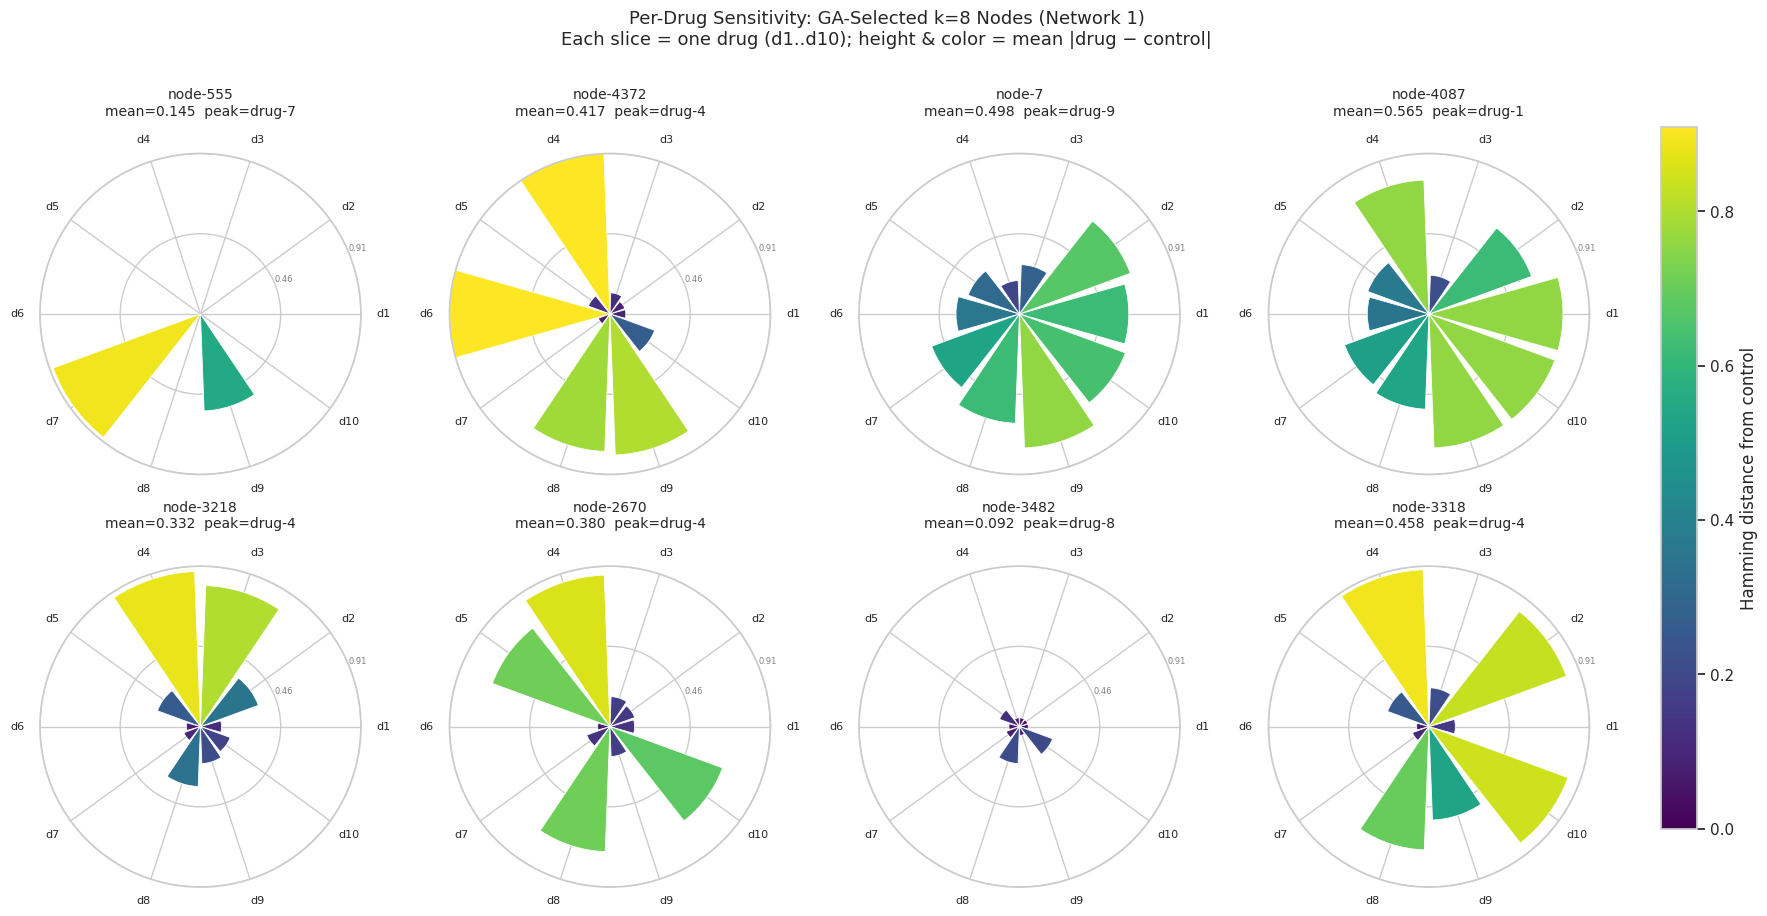

Saved → plots/node-drug-sensitivity-disk-network-5.png


In [31]:
n_drugs = len(all_drugs)
theta = np.linspace(0, 2 * np.pi, n_drugs, endpoint=False)
width = 2 * np.pi / n_drugs

vmax = hamming_df.values.max()
cmap = cm.viridis
norm = mcolors.Normalize(vmin=0, vmax=vmax)

fig, axes = plt.subplots(
    2, 4, figsize=(18, 9),
    subplot_kw={'projection': 'polar'}
)

for ax, node_col in zip(axes.flat, NODE_COLS):
    values = hamming_df[node_col].values  # shape (10,)
    colors = [cmap(norm(v)) for v in values]

    ax.bar(
        theta, values,
        width=width * 0.88,
        bottom=0,
        color=colors,
        align='center',
        edgecolor='white',
        linewidth=0.6,
    )

    ax.set_xticks(theta)
    ax.set_xticklabels([f'd{i+1}' for i in range(n_drugs)], fontsize=8)
    ax.set_ylim(0, vmax)
    ax.set_yticks([vmax / 2, vmax])
    ax.set_yticklabels([f'{vmax/2:.2f}', f'{vmax:.2f}'], fontsize=6, color='gray')

    mean_h = hamming_df[node_col].mean()
    max_drug = all_drugs[hamming_df[node_col].values.argmax()]
    ax.set_title(
        f'{node_col}\nmean={mean_h:.3f}  peak={max_drug}',
        fontsize=10, pad=14,
    )

fig.suptitle(
    'Per-Drug Sensitivity: GA-Selected k=8 Nodes (Network 1)\n'
    'Each slice = one drug (d1..d10); height & color = mean |drug − control|',
    fontsize=13, y=1.01,
)

# Colorbar in a dedicated axes so it doesn't overlap the polar charts
plt.tight_layout(rect=[0, 0, 0.92, 1])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.78])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Hamming distance from control')

plt.savefig(f'../plots/node-drug-sensitivity-disk-network-{NETWORK_IDX}.png', dpi=600, bbox_inches='tight')
plt.show()
print(f'Saved → plots/node-drug-sensitivity-disk-network-{NETWORK_IDX}.png')

## Section 3: Summary Heatmap

Compact view of the same data: rows = drugs, columns = nodes.
Exact values annotated; same colormap scale as the disk plots.

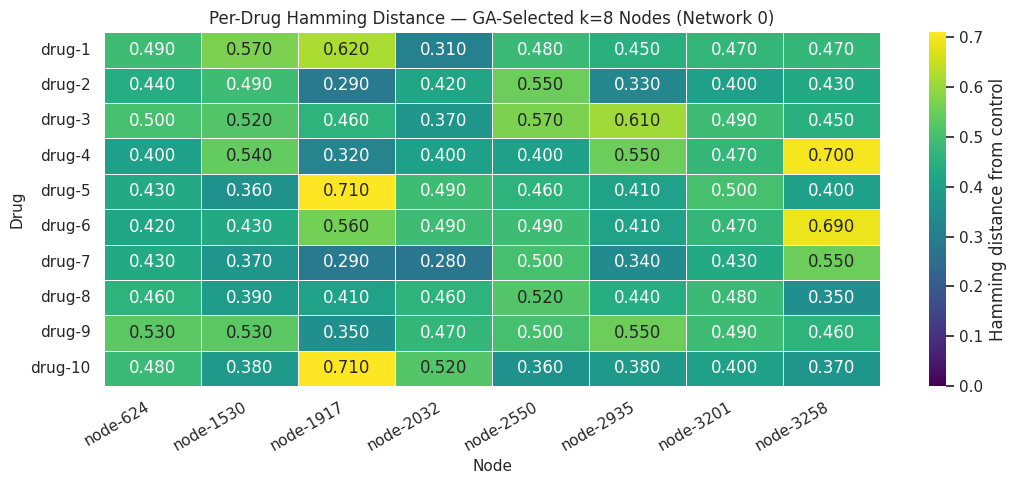

Saved → plots/node-drug-sensitivity-heatmap.png


In [12]:
fig, ax = plt.subplots(figsize=(11, 5))

sns.heatmap(
  hamming_df,
  annot=True,
  fmt='.3f',
  cmap='viridis',
  vmin=0,
  vmax=vmax,
  linewidths=0.4,
  linecolor='white',
  ax=ax,
  cbar_kws={'label': 'Hamming distance from control'},
)

ax.set_xlabel('Node', fontsize=11)
ax.set_ylabel('Drug', fontsize=11)
ax.set_title(
  'Per-Drug Hamming Distance — GA-Selected k=8 Nodes (Network 0)',
  fontsize=12,
)

# Rotate x-tick labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../plots/node-drug-sensitivity-heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plots/node-drug-sensitivity-heatmap.png')

## Section 4: Per-Node Drug Ranking

For each node, which drug perturbs it the most? Useful for quickly identifying
which nodes are most specific to which perturbation.

In [13]:
print('Top drug per node (highest Hamming distance):')
for node_col in NODE_COLS:
  top_drug = hamming_df[node_col].idxmax()
  top_val  = hamming_df[node_col].max()
  bot_drug = hamming_df[node_col].idxmin()
  bot_val  = hamming_df[node_col].min()
  print(f'  {node_col}: max={top_drug} ({top_val:.3f}),  min={bot_drug} ({bot_val:.3f})')

print('\nTop node per drug (highest Hamming distance):')
for drug in all_drugs:
  top_node = hamming_df.loc[drug].idxmax()
  top_val  = hamming_df.loc[drug].max()
  print(f'  {drug}: {top_node} ({top_val:.3f})')

Top drug per node (highest Hamming distance):
  node-624: max=drug-9 (0.530),  min=drug-4 (0.400)
  node-1530: max=drug-1 (0.570),  min=drug-5 (0.360)
  node-1917: max=drug-5 (0.710),  min=drug-2 (0.290)
  node-2032: max=drug-10 (0.520),  min=drug-7 (0.280)
  node-2550: max=drug-3 (0.570),  min=drug-10 (0.360)
  node-2935: max=drug-3 (0.610),  min=drug-2 (0.330)
  node-3201: max=drug-5 (0.500),  min=drug-2 (0.400)
  node-3258: max=drug-4 (0.700),  min=drug-8 (0.350)

Top node per drug (highest Hamming distance):
  drug-1: node-1917 (0.620)
  drug-2: node-2550 (0.550)
  drug-3: node-2935 (0.610)
  drug-4: node-3258 (0.700)
  drug-5: node-1917 (0.710)
  drug-6: node-3258 (0.690)
  drug-7: node-3258 (0.550)
  drug-8: node-2550 (0.520)
  drug-9: node-2935 (0.550)
  drug-10: node-1917 (0.710)


## Section 5: Cross-Network Rank-Ordered Disk Plots

Average per-drug sensitivity across all 50 networks, aligned by **sensitivity rank** rather than node identity.

For each network:
1. Get the GA-best k=8 nodes (final generation, `max_num_features=8`)
2. Compute per-drug Hamming distances for those 8 nodes
3. Rank the 8 nodes by their mean Hamming distance (averaged over all 10 drugs), descending
4. Store a `(8 ranks × 10 drugs)` matrix

Then average the ranked matrices across all 50 networks. Each disk plot represents a **sensitivity rank** rather than a specific node — e.g. "what does the most sensitive sensor in the GA k=8 set typically look like across networks?"

In [14]:
from pathlib import Path

GA_RESULTS_DIR = '../data/drug-fixed-targets-v7/N5000/ga-results-v7'
NUM_NETWORKS = 50

# Load per-network GA result CSVs
full_csvs = sorted(Path(GA_RESULTS_DIR).glob('*-full.csv'))
full_csvs = [c for c in full_csvs if not c.name.startswith('combined')]
print(f'Found {len(full_csvs)} per-network GA result files')

feature_df = pd.concat([pd.read_csv(f) for f in full_csvs], ignore_index=True)
feature_df['features'] = feature_df['features'].apply(eval)

# Extract best k=8 node set for each network (final generation)
best_k8 = {}
for orig_idx in range(NUM_NETWORKS):
    fdf = feature_df[
        (feature_df.original_network_idx == orig_idx) &
        (feature_df.max_num_features == 8)
    ]
    if fdf.empty:
        continue
    max_gen = fdf.generation.max()
    best_row = fdf[fdf.generation == max_gen].iloc[0]
    nodes = sorted([int(n.split('-')[1]) for n in best_row.features])
    best_k8[orig_idx] = nodes

print(f'Loaded k=8 best sets for {len(best_k8)} networks')
print(f'Network 0 nodes (should match Section 1): {best_k8[0]}')

Found 50 per-network GA result files
Loaded k=8 best sets for 50 networks
Network 0 nodes (should match Section 1): [624, 1530, 1917, 2032, 2550, 2935, 3201, 3258]


In [16]:
# For each network: compute per-drug Hamming distances for its k=8 nodes,
# then rank nodes by mean sensitivity (desc). Average ranked matrices across networks.

per_network_ranked = []  # will become shape (n_networks, 8 ranks, 10 drugs)

for orig_idx, nodes in best_k8.items():
    node_cols_net = [f'node-{n}' for n in nodes]
    df_net = states_df[states_df['original_network_idx'] == orig_idx]

    ctrl = (
        df_net[df_net['drug_name'] == 'control']
        .set_index(['initial_condition_idx', 'step_num'])[node_cols_net]
        .astype(float)
        .sort_index()
    )

    # Build (8 nodes × 10 drugs) Hamming matrix for this network
    drug_vecs = []
    for drug in all_drugs:
        treated = (
            df_net[df_net['drug_name'] == drug]
            .set_index(['initial_condition_idx', 'step_num'])[node_cols_net]
            .astype(float)
            .sort_index()
        )
        diff = np.abs(treated.values - ctrl.values)  # (100, 8)
        drug_vecs.append(diff.mean(axis=0))           # (8,)

    hamming_mat = np.column_stack(drug_vecs)          # (8 nodes, 10 drugs)

    # Rank nodes by mean Hamming distance across drugs (desc: rank 0 = most sensitive)
    mean_by_node = hamming_mat.mean(axis=1)
    rank_order = np.argsort(mean_by_node)[::-1]
    per_network_ranked.append(hamming_mat[rank_order])  # (8, 10)

    if orig_idx % 10 == 0:
        print(f'  network {orig_idx}: mean by rank = {mean_by_node[rank_order].round(3)}')

per_network_ranked = np.array(per_network_ranked)  # (50, 8, 10)
avg_ranked = per_network_ranked.mean(axis=0)        # (8, 10)
std_ranked  = per_network_ranked.std(axis=0)        # (8, 10)

print(f'\nShape: {per_network_ranked.shape}  →  avg_ranked: {avg_ranked.shape}')
print('\nMean sensitivity by rank (avg over drugs then networks):')
for r in range(8):
    label = 'most sensitive' if r == 0 else ('least sensitive' if r == 7 else '')
    print(f'  Rank {r+1}: {avg_ranked[r].mean():.3f} ± {std_ranked[r].mean():.3f}  {label}')

  network 0: mean by rank = [0.487 0.483 0.472 0.46  0.458 0.458 0.447 0.421]
  network 10: mean by rank = [0.553 0.532 0.49  0.485 0.467 0.349 0.211 0.046]
  network 20: mean by rank = [0.513 0.502 0.493 0.482 0.482 0.463 0.372 0.   ]
  network 30: mean by rank = [0.539 0.517 0.508 0.484 0.484 0.428 0.395 0.115]
  network 40: mean by rank = [0.526 0.5   0.49  0.483 0.464 0.457 0.392 0.235]

Shape: (50, 8, 10)  →  avg_ranked: (8, 10)

Mean sensitivity by rank (avg over drugs then networks):
  Rank 1: 0.511 ± 0.159  most sensitive
  Rank 2: 0.482 ± 0.152  
  Rank 3: 0.451 ± 0.166  
  Rank 4: 0.425 ± 0.192  
  Rank 5: 0.386 ± 0.191  
  Rank 6: 0.330 ± 0.206  
  Rank 7: 0.244 ± 0.218  
  Rank 8: 0.109 ± 0.174  least sensitive


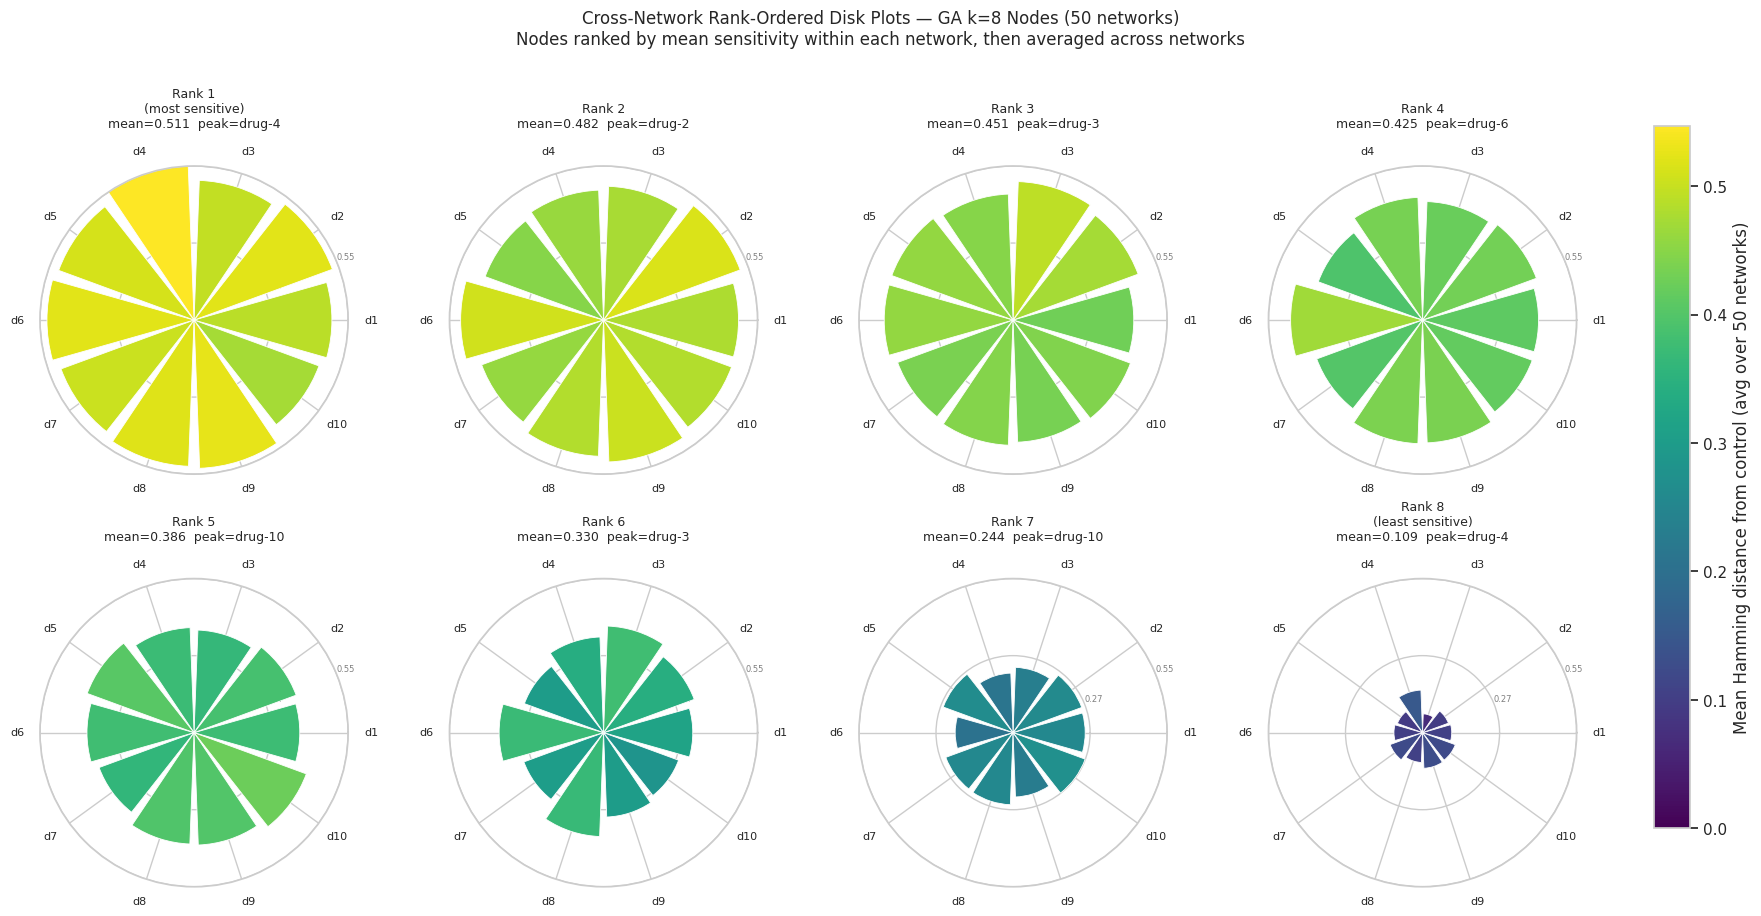

Saved → plots/node-drug-sensitivity-ranked-disk.png


In [19]:
vmax_ranked = avg_ranked.max()
norm_ranked  = mcolors.Normalize(vmin=0, vmax=vmax_ranked)

rank_titles = [
    'Rank 1\n(most sensitive)', 'Rank 2', 'Rank 3', 'Rank 4',
    'Rank 5', 'Rank 6', 'Rank 7', 'Rank 8\n(least sensitive)',
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9), subplot_kw={'projection': 'polar'})

for rank, ax in enumerate(axes.flat):
    values = avg_ranked[rank]   # mean Hamming per drug for this rank, shape (10,)
    colors = [cmap(norm_ranked(v)) for v in values]

    ax.bar(
        theta, values,
        width=width * 0.88,
        bottom=0,
        color=colors,
        align='center',
        edgecolor='white',
        linewidth=0.6,
    )

    ax.set_xticks(theta)
    ax.set_xticklabels([f'd{i+1}' for i in range(n_drugs)], fontsize=8)
    ax.set_ylim(0, vmax_ranked)
    ax.set_yticks([vmax_ranked / 2, vmax_ranked])
    ax.set_yticklabels([f'{vmax_ranked/2:.2f}', f'{vmax_ranked:.2f}'], fontsize=6, color='gray')

    peak_drug = all_drugs[values.argmax()]
    ax.set_title(
        f'{rank_titles[rank]}\nmean={values.mean():.3f}  peak={peak_drug}',
        fontsize=9, pad=14,
    )

fig.suptitle(
    'Cross-Network Rank-Ordered Disk Plots — GA k=8 Nodes (50 networks)\n'
    'Nodes ranked by mean sensitivity within each network, then averaged across networks',
    fontsize=12, y=1.01,
)

# Colorbar in a dedicated axes so it doesn't overlap the polar charts
plt.tight_layout(rect=[0, 0, 0.92, 1])
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.78])
sm_r = cm.ScalarMappable(cmap=cmap, norm=norm_ranked)
sm_r.set_array([])
fig.colorbar(sm_r, cax=cbar_ax, label='Mean Hamming distance from control (avg over 50 networks)')

plt.savefig('../plots/node-drug-sensitivity-ranked-disk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plots/node-drug-sensitivity-ranked-disk.png')

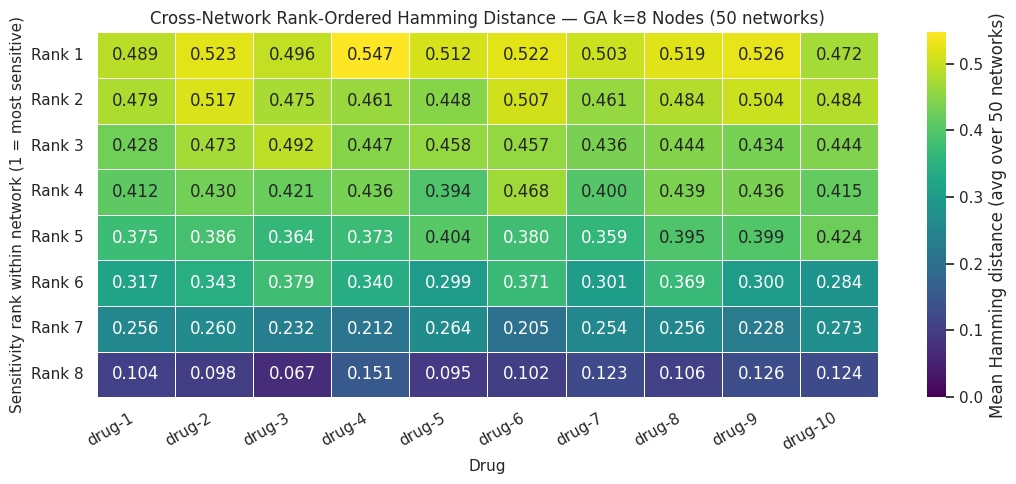

Saved → plots/node-drug-sensitivity-ranked-heatmap.png


In [18]:
ranked_df = pd.DataFrame(
    avg_ranked,
    index=[f'Rank {r+1}' for r in range(8)],
    columns=all_drugs,
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    ranked_df,
    annot=True,
    fmt='.3f',
    cmap='viridis',
    vmin=0,
    vmax=vmax_ranked,
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Mean Hamming distance (avg over 50 networks)'},
)
ax.set_xlabel('Drug', fontsize=11)
ax.set_ylabel('Sensitivity rank within network (1 = most sensitive)', fontsize=11)
ax.set_title(
    'Cross-Network Rank-Ordered Hamming Distance — GA k=8 Nodes (50 networks)',
    fontsize=12,
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../plots/node-drug-sensitivity-ranked-heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plots/node-drug-sensitivity-ranked-heatmap.png')